In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [ ]:
!gdown 16TAoRZ3S8ebgIq3dPQmWIXPw_1dZy3ta

Downloading...
From: https://drive.google.com/uc?id=16TAoRZ3S8ebgIq3dPQmWIXPw_1dZy3ta
To: /content/rest_vis.csv
100% 13.1k/13.1k [00:00<00:00, 25.5MB/s]


In [ ]:
df = pd.read_csv('/content/rest_vis.csv')
df.head()

,date,weekday,holiday,total
0,1/1/2016,Friday,1,296.0
1,1/2/2016,Saturday,0,191.0
2,1/3/2016,Sunday,0,202.0
3,1/4/2016,Monday,0,105.0
4,1/5/2016,Tuesday,0,98.0


In [ ]:
df['date'] = pd.to_datetime(df['date'])

# Set date as index
df = df.set_index('date').sort_index()

In [ ]:
df.dropna(inplace = True)

In [ ]:
df.head()

,weekday,holiday,total
date,,,
2016-01-01,Friday,1,296.0
2016-01-02,Saturday,0,191.0
2016-01-03,Sunday,0,202.0
2016-01-04,Monday,0,105.0
2016-01-05,Tuesday,0,98.0


In [ ]:
weekend_days = {"Friday", "Saturday", "Sunday"}

df["is_weekend"] = df["weekday"].isin(weekend_days).astype(int)
df["is_weekday"] = (1 - df["is_weekend"]).astype(int)

In [ ]:
df.head()

,weekday,holiday,total,is_weekend,is_weekday
date,,,,,
2016-01-01,Friday,1,296.0,1,0
2016-01-02,Saturday,0,191.0,1,0
2016-01-03,Sunday,0,202.0,1,0
2016-01-04,Monday,0,105.0,0,1
2016-01-05,Tuesday,0,98.0,0,1


In [ ]:
exog = df[['is_weekend', 'is_weekday', 'holiday']]

In [ ]:
train_x = df[['total']].iloc[:464]
test_x  = df[['total']].iloc[464:]

train_exog = exog.iloc[:464]
test_exog  = exog.iloc[464:]

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# order and seasonal order finalized in previous session

model = SARIMAX(
    train_x['total'],
    exog=train_exog,
    order=(6,0,6),
    seasonal_order=(3,1,2,7)
)

results = model.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
forecast_1 = results.forecast(steps=len(test_x), exog=test_exog)

(array([17265., 17267., 17269., 17271., 17273., 17275., 17277.]),
 [Text(17265.0, 0, '2017-04-09'),
  Text(17267.0, 0, '2017-04-11'),
  Text(17269.0, 0, '2017-04-13'),
  Text(17271.0, 0, '2017-04-15'),
  Text(17273.0, 0, '2017-04-17'),
  Text(17275.0, 0, '2017-04-19'),
  Text(17277.0, 0, '2017-04-21')])

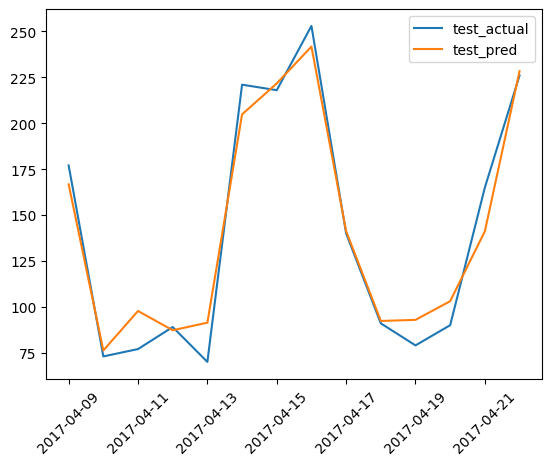

In [ ]:
plt.plot(test_x,label='test_actual')
plt.plot(forecast_1, label='test_pred')
plt.legend()
plt.xticks(rotation=45)

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error as mape

mape(test_x, forecast_1)

0.09509181339406214

# Using Linear Regression

In [ ]:
df

,weekday,holiday,total,is_weekend,is_weekday
date,,,,,
2016-01-01,Friday,1,296.0,1,0
2016-01-02,Saturday,0,191.0,1,0
2016-01-03,Sunday,0,202.0,1,0
2016-01-04,Monday,0,105.0,0,1
2016-01-05,Tuesday,0,98.0,0,1
...,...,...,...,...,...
2017-04-18,Tuesday,0,91.0,0,1
2017-04-19,Wednesday,0,79.0,0,1
2017-04-20,Thursday,0,90.0,0,1


In [ ]:
df['lag_1']  = df['total'].shift(1)
df['lag_2']  = df['total'].shift(2)
df['lag_3']  = df['total'].shift(3)
df['lag_4']  = df['total'].shift(4)
df['lag_5']  = df['total'].shift(5)
df['lag_6']  = df['total'].shift(6)
df['lag_7']  = df['total'].shift(7)
df['lag_14'] = df['total'].shift(14)

In [ ]:
feature_cols = [
    'is_weekend',
    'is_weekday',
    'holiday',
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_4',
    'lag_5',
    'lag_6',
    'lag_7',
    'lag_14'

]

df_model = df.dropna().copy()

In [ ]:
df_model.head()

,weekday,holiday,total,is_weekend,is_weekday,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_14
date,,,,,,,,,,,,,
2016-01-15,Friday,0,95.0,1,0,106.0,65.0,57.0,101.0,212.0,234.0,149.0,296.0
2016-01-16,Saturday,0,237.0,1,0,95.0,106.0,65.0,57.0,101.0,212.0,234.0,191.0
2016-01-17,Sunday,0,197.0,1,0,237.0,95.0,106.0,65.0,57.0,101.0,212.0,202.0
2016-01-18,Monday,1,132.0,0,1,197.0,237.0,95.0,106.0,65.0,57.0,101.0,105.0
2016-01-19,Tuesday,0,100.0,0,1,132.0,197.0,237.0,95.0,106.0,65.0,57.0,98.0


In [ ]:
X = df_model[feature_cols]
y = df_model['total']

In [ ]:
df_model

,weekday,holiday,total,is_weekend,is_weekday,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_14
date,,,,,,,,,,,,,
2016-01-15,Friday,0,95.0,1,0,106.0,65.0,57.0,101.0,212.0,234.0,149.0,296.0
2016-01-16,Saturday,0,237.0,1,0,95.0,106.0,65.0,57.0,101.0,212.0,234.0,191.0
2016-01-17,Sunday,0,197.0,1,0,237.0,95.0,106.0,65.0,57.0,101.0,212.0,202.0
2016-01-18,Monday,1,132.0,0,1,197.0,237.0,95.0,106.0,65.0,57.0,101.0,105.0
2016-01-19,Tuesday,0,100.0,0,1,132.0,197.0,237.0,95.0,106.0,65.0,57.0,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-04-18,Tuesday,0,91.0,0,1,140.0,253.0,218.0,221.0,70.0,89.0,77.0,99.0
2017-04-19,Wednesday,0,79.0,0,1,91.0,140.0,253.0,218.0,221.0,70.0,89.0,98.0
2017-04-20,Thursday,0,90.0,0,1,79.0,91.0,140.0,253.0,218.0,221.0,70.0,74.0


In [ ]:
split_idx = 450 # adjust index

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

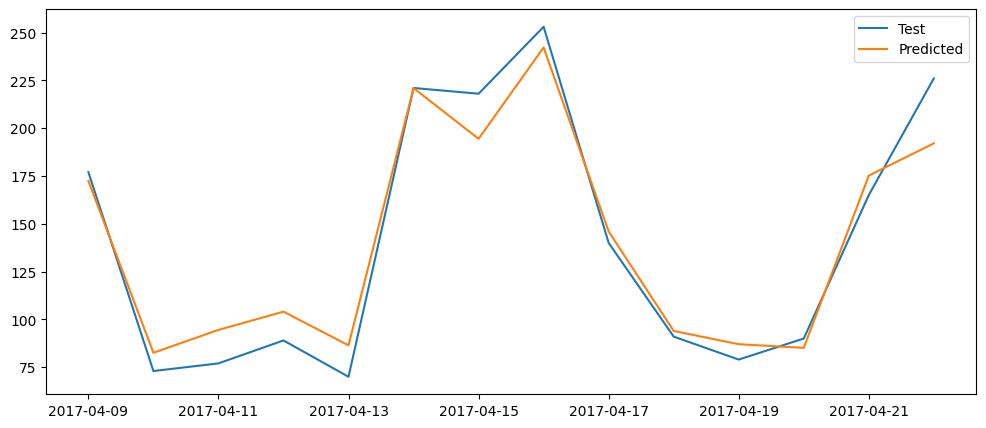

In [ ]:
y_pred = lr.predict(X_test)
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Test')
plt.plot(y_test.index, y_pred, label='Predicted')

plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error as mape

mape(y_test, y_pred)

0.09873508649580622

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.06,
    max_depth=2,
    subsample=1,
    colsample_bytree=1,
    objective='reg:squarederror'
)

xgb.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.06, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, ...)

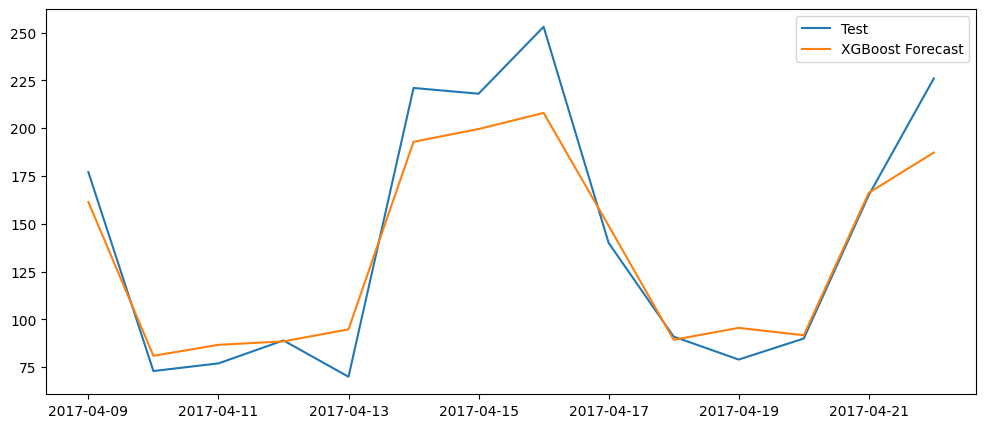

In [ ]:
y_pred_xgb = xgb.predict(X_test)
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test, label='Test')
plt.plot(y_test.index, y_pred_xgb, label='XGBoost Forecast')

plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error as mape

mape(y_test, y_pred_xgb)

0.11164755740154793

# Prophet

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [ ]:
df = pd.read_csv('/content/rest_vis.csv')
df.head()

,date,weekday,holiday,total
0,1/1/2016,Friday,1,296.0
1,1/2/2016,Saturday,0,191.0
2,1/3/2016,Sunday,0,202.0
3,1/4/2016,Monday,0,105.0
4,1/5/2016,Tuesday,0,98.0


In [ ]:
df['date'] = pd.to_datetime(df['date'])

# Set date as index
df = df.set_index('date').sort_index()

In [ ]:
df

,weekday,holiday,total
date,,,
2016-01-01,Friday,1,296.0
2016-01-02,Saturday,0,191.0
2016-01-03,Sunday,0,202.0
2016-01-04,Monday,0,105.0
2016-01-05,Tuesday,0,98.0
...,...,...,...
2017-05-27,Saturday,0,NaN
2017-05-28,Sunday,0,NaN
2017-05-29,Monday,1,NaN


In [ ]:
df.dropna(inplace = True)

In [ ]:
weekend_days = {"Friday", "Saturday", "Sunday"}

df["is_weekend"] = df["weekday"].isin(weekend_days).astype(int)
df["is_weekday"] = (1 - df["is_weekend"]).astype(int)

In [ ]:
df

,weekday,holiday,total,is_weekend,is_weekday
date,,,,,
2016-01-01,Friday,1,296.0,1,0
2016-01-02,Saturday,0,191.0,1,0
2016-01-03,Sunday,0,202.0,1,0
2016-01-04,Monday,0,105.0,0,1
2016-01-05,Tuesday,0,98.0,0,1
...,...,...,...,...,...
2017-04-18,Tuesday,0,91.0,0,1
2017-04-19,Wednesday,0,79.0,0,1
2017-04-20,Thursday,0,90.0,0,1


In [ ]:
df_prophet = df.reset_index().rename(columns={
    'date': 'ds',
    'total': 'y'
})

# Select exogenous variable names
exog_cols = ['holiday', 'is_weekend', 'is_weekday']

In [ ]:
df_prophet.drop('weekday',axis=1,inplace=True)

In [ ]:
df_prophet

,ds,holiday,y,is_weekend,is_weekday
0,2016-01-01,1,296.0,1,0
1,2016-01-02,0,191.0,1,0
2,2016-01-03,0,202.0,1,0
3,2016-01-04,0,105.0,0,1
4,2016-01-05,0,98.0,0,1
...,...,...,...,...,...
473,2017-04-18,0,91.0,0,1
474,2017-04-19,0,79.0,0,1
475,2017-04-20,0,90.0,0,1
476,2017-04-21,0,165.0,1,0


In [ ]:
train = df_prophet.iloc[:450].copy()
test  = df_prophet.iloc[450:].copy()

In [ ]:
!pip uninstall prophet pystan -y
!pip install prophet
!pip install cmdstanpy

Found existing installation: prophet 1.2.1
Uninstalling prophet-1.2.1:
  Successfully uninstalled prophet-1.2.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 65.1 MB/s eta 0:00:00


In [ ]:
from prophet import Prophet

#changepoint between 0 and 1
# seasonality_prior_scale - 0 to 20
# holidays_prior_scale - 0 to 20
m = Prophet(changepoint_prior_scale=0.8, seasonality_prior_scale=5,holidays_prior_scale=5)

# add regressors
for col in exog_cols:
    m.add_regressor(col)

m.add_seasonality(
    name='monthly',
    period=30.5,
    fourier_order=2
)



m.add_country_holidays(country_name='IN')


# fit
m.fit(train)

/usr/local/lib/python3.12/dist-packages/holidays/countries/india.py:202: Warning: Requested Holidays are available only from 2001 to 2035.
  warnings.warn(warning_msg, Warning)
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = test[['ds'] + exog_cols]
forecast = m.predict(future)

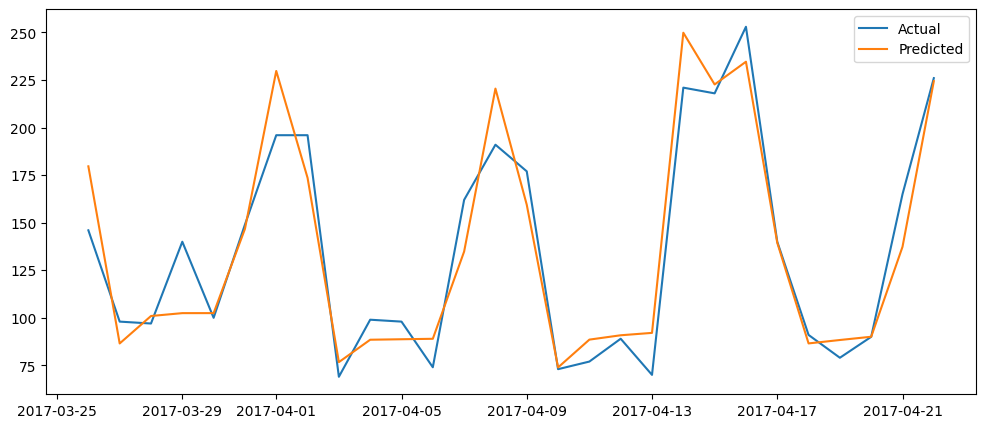

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(test['ds'], test['y'], label='Actual')
plt.plot(test['ds'], forecast['yhat'], label='Predicted')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error as mape

mape(test['y'], forecast['yhat'])

0.10671340447885481

In [ ]:
df

,weekday,holiday,total,is_weekend,is_weekday
date,,,,,
2016-01-01,Friday,1,296.0,1,0
2016-01-02,Saturday,0,191.0,1,0
2016-01-03,Sunday,0,202.0,1,0
2016-01-04,Monday,0,105.0,0,1
2016-01-05,Tuesday,0,98.0,0,1
...,...,...,...,...,...
2017-04-18,Tuesday,0,91.0,0,1
2017-04-19,Wednesday,0,79.0,0,1
2017-04-20,Thursday,0,90.0,0,1


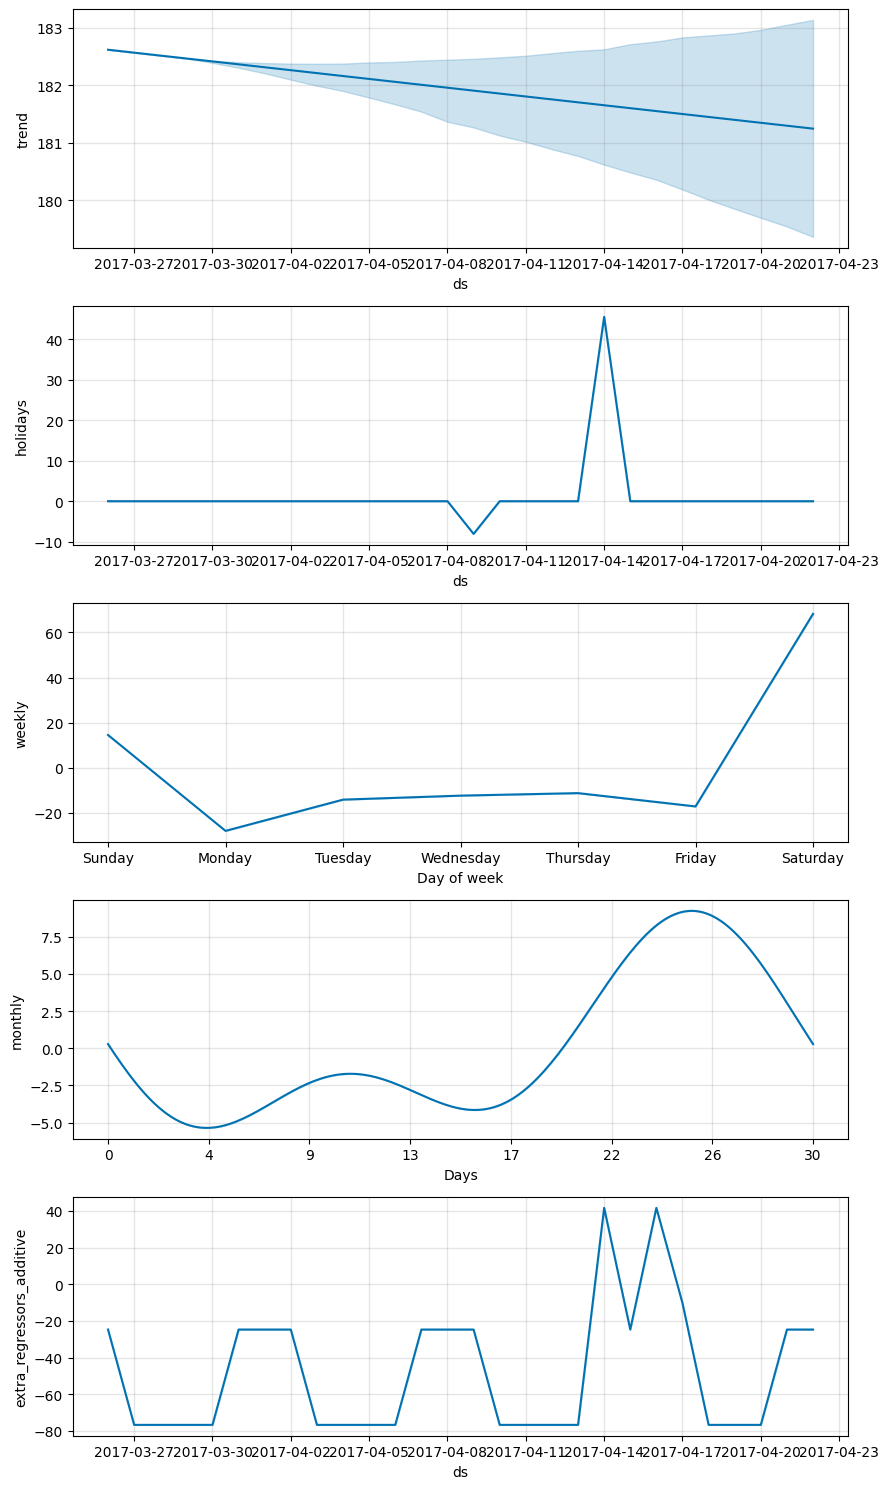

In [ ]:
from prophet.plot import plot_components

fig = m.plot_components(forecast)

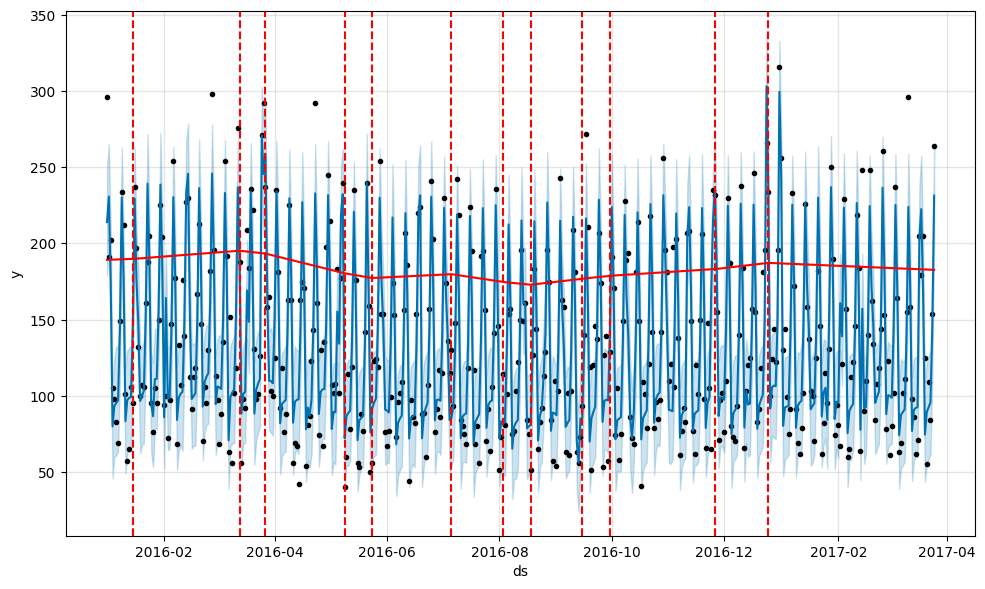

In [ ]:
from prophet.plot import add_changepoints_to_plot
import matplotlib.pyplot as plt

train_future = train[['ds'] + exog_cols]
train_pred = m.predict(train_future)
fig = m.plot(train_pred)
_ = add_changepoints_to_plot(fig.gca(), m, train_pred)

In [ ]:
a